<a href="https://colab.research.google.com/github/makson4ik7557/Intelligent_analysis/blob/main/Copy_of_%D0%9B%D0%A01_%D0%B7%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_%D1%81%D1%82%D1%83%D0%B4%D0%B5%D0%BD%D1%82%D1%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота № 1

## Вхідний аналіз набору даних

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Пригадати роботу в Jupyter Notebook, бібліотеці `pandas` та побудову графіків —
і зробити це не на навчальному прикладі, а на реальному файлі, який ніхто не готував
спеціально для вас.

Ця робота виконується **до першої лекції**. Нічого нового знати не потрібно: усе,
що знадобиться, ви вже проходили в попередніх курсах. Усі поняття, яких ви тут
торкнетеся мимохідь, отримають назви й пояснення на лекціях 3 і 4.

### Дані

Файл `20171129_FINAL_FINAL.xlsx`, аркуш `Sheet1` — спостереження космічної погоди
за 28 серпня — 22 вересня 2017 року, зібрані з трьох різних джерел.

Файл видається **як є**, рівно в тому вигляді, у якому його колись вивантажили.
Ніхто не приводив його до ладу, і саме в цьому сенс: справжні дані здебільшого
надходять саме такими.

### Що ви маєте зробити

| Етап | Зміст | Де |
|---|---|---|
| 1 | Розібратися, що взагалі лежить у файлі | аудиторно |
| 2 | Виділити три таблиці й привести їх до робочого вигляду | аудиторно |
| 3 | Скласти паспорт даних: що є, чого бракує, що виглядає дивно | аудиторно |
| 4 | Об'єднати три таблиці в одну | аудиторно |
| 5 | Побудувати п'ять графіків, кожен — відповідь на питання | аудиторно + самостійно |
| 6 | Порівняти два графіки одних і тих самих даних | самостійно |
| 7 | Записати три спостереження про дані | самостійно |
| 8 | Декларація про використання інструментів ШІ | самостійно |

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Ноутбук має виконуватися згори
   донизу на чистому ядрі** (Kernel → Restart & Run All) без помилок — це перевіряється
   першою дією на захисті.
2. Файл `master_hourly.csv` — об'єднана таблиця з етапу 4.
3. Експорт ноутбука у HTML або PDF.
4. Заповнена декларація (етап 8). Без неї фінальна самоперевірка не проходить.

### Критерії оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Дані не опрацьовано, графіки не побудовано або побудовано з грубими помилками |
| 1 | Таблиці прочитано й кілька графіків побудовано, але типи графіків не відповідають даним, дивних значень не помічено |
| 2 | Таблиці розібрано й об'єднано, графіки коректні та підписані, але висновків під ними немає або вони формальні |
| 4 | Усе вище виконано, знайдено й пояснено дивні значення, під кожним графіком є змістовний висновок про дані |

**Головне про оцінку:** бали ставляться не за наявність графіка, а за речення під ним.
Код, який нічого не пояснює, коштує двох балів з чотирьох.

---
## Нагадування про Jupyter

Якщо давно не працювали — три речі, які знадобляться сьогодні:

* `Shift+Enter` виконує клітинку, `Esc` `A` / `Esc` `B` додає клітинку вище / нижче,
  `Esc` `M` перетворює клітинку на текстову (Markdown), `Esc` `Y` — назад на код.
* **Порядок виконання має значення.** Якщо ви правили клітинки в довільному порядку,
  результат може залежати від історії запусків. Перед здачею обов'язково
  **Kernel → Restart & Run All** — так ви побачите ноутбук очима викладача.
* Текстові клітинки — не прикраса. Висновки пишуться в них, а не в коментарях до коду.

---
## Крок 0. Ваші дані та варіант

Заповніть три змінні й виконайте обидві клітинки. Друга надрукує **ваше
індивідуальне завдання** — воно відрізняється від завдання сусіда.

In [ ]:
ПІБ = 'Мартин Максим Ігорович'
ГРУПА = 'ШІ-31'
ВАРІАНТ = 14

assert ПІБ and ГРУПА and ВАРІАНТ, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ'

In [ ]:
# --- клітинку не редагувати: вона видає ваше персональне завдання ------------
ПОТОКИ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

ПАРИ = [('швидкість вітру', 'густина вітру'),
        ('швидкість вітру', 'потік P>10'),
        ('густина вітру', 'потік P>1'),
        ('радіопотік F10.7', 'потік P>10'),
        ('радіопотік F10.7', 'швидкість вітру'),
        ('потік E>0.8', 'потік P>10')]

АГРЕГАТИ = ['середнє', 'максимум', 'медіана', 'мінімум']

ПИТАННЯ = [
    'Скільки годин за все вікно ваш потік перевищував своє власне медіанне значення?',
    'У яку добу середнє значення вашого потоку було найбільшим? А найменшим?',
    'О котрій годині доби потік E>0.8 у середньому найбільший? Побудуйте графік середнього за годинами доби.',
    'Яка частка рядків об’єднаної таблиці має пропуск хоча б в одному стовпці?',
    'У який день радіопотік F10.7 був найбільшим і чи збігається цей день з піком вашого потоку?',
    'Порівняйте медіану вашого потоку за перший і за другий тиждень спостережень. У скільки разів вони відрізняються?',
    'Скільки годин поспіль тривала найдовша неперервна серія «активних» годин (група з етапу 4)?',
    'Який зі стовпців об’єднаної таблиці має найбільший розкид відносно власного середнього?',
    'Яку частку сумарного значення вашого потоку за все вікно дали 24 години навколо піку?',
    'Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?',
]

i = int(ВАРІАНТ)
завдання = {
    'ваш потік':                      ПОТОКИ[(i * 3 + 1) % 8],
    'ваша пара для графіка 3':        ' та '.join(ПАРИ[(i * 5 + 2) % 6]),
    'ваш агрегат для етапу 4':        АГРЕГАТИ[(i * 5 + 1) % 4],
    'ваше додаткове питання':         ПИТАННЯ[(i * 11 + 5) % 10],
}

print('ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · %s, %s, варіант %d' % (ПІБ, ГРУПА, i))
print('=' * 78)
for k, v in завдання.items():
    print('%-28s %s' % (k + ':', v))

ІНДИВІДУАЛЬНЕ ЗАВДАННЯ · Мартин Максим Ігорович, ШІ-31, варіант 14
ваш потік:                   P>30
ваша пара для графіка 3:     швидкість вітру та густина вітру
ваш агрегат для етапу 4:     мінімум
ваше додаткове питання:      Скільки різних діб потрапило у групу «активні» і скільки — у групу «дуже активні»?


Далі за текстом **«ваш потік»** означає стовпець, названий у першому рядку завдання.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

ФАЙЛ = '20171129_FINAL_FINAL.xlsx'

---
# Етап 1. Що взагалі лежить у файлі

Перше правило роботи з незнайомими даними: спершу подивитися, потім рахувати.

### Завдання 1.1
Спробуйте прочитати аркуш `Sheet1` звичайним способом — `pd.read_excel(ФАЙЛ)` —
і виведіть перші рядки та типи стовпців.

*Очікуваний результат: результат буде дивним. Подивіться на назви стовпців і на
те, які там типи даних. Поясніть у наступній клітинці, чому так вийшло.*

In [ ]:
проба = pd.read_excel(ФАЙЛ)

print('розмір:', проба.shape)
print()
print('перші 6 назв стовпців:')
for назва in list(проба.columns)[:6]:
    print('   ', repr(назва))
print()
print('скільки стовпців якого типу:')
print(проба.dtypes.value_counts().to_string())
print()
display(проба.head())

розмір: (7225, 32)

перші 6 назв стовпців:
    'Unnamed: 0'
    'ftp://ftp.swpc.noaa.gov/pub/lists/particle/'
    'Unnamed: 2'
    'Unnamed: 3'
    'Unnamed: 4'
    'Unnamed: 5'

скільки стовпців якого типу:
object     24
float64     8



,Unnamed: 0,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,http://umtof.umd.edu/pm/crn/,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
2,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
3,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
4,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN


**Відповідь 1.1:** *(чому звичайне читання дало саме такий результат)*
read_excel за замовчуванням бере перший рядок аркуша за заголовок. У цьому рядку заповнена лише одна клітинка з ftp-посиланням, тому один стовпець отримав назву-посилання, решта 31 стали Unnamed: N, а сам рядок зник із даних (7225 замість 7226). Нижче в кожному стовпці впереміш лежать службовий текст і числа, тому pandas не зміг вивести числовий тип і залишив 24 стовпці як object. Числовими стали лише 8, і це порожні стовпці-роздільники та два лічильники рядків, тобто жоден стовпець із вимірюваннями. Рахувати по такій таблиці неможливо. Крім того, три різні таблиці, вставлені в аркуш поруч, злиплися в одну прямокутну сітку. Читання не помилилося, просто припущення «перший рядок це заголовок, а аркуш це одна таблиця» до цього файлу не підходить.

### Завдання 1.2
Прочитайте аркуш ще раз, але **без заголовка**: `pd.read_excel(ФАЙЛ, header=None)`.
Виведіть його розмір і подивіться на перші 30 рядків.

In [ ]:
RAW = pd.read_excel(ФАЙЛ, header=None)

print('розмір аркуша:', RAW.shape)
display(RAW.head(30))

розмір аркуша: (7226, 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31
0,NaN,ftp://ftp.swpc.noaa.gov/pub/lists/particle/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,http://umtof.umd.edu/pm/crn/,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,:Data_list: 20170901_Gs_part_5m.txt,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SOHO CELIAS Proton Monitor,NaN,NaN,NaN,NaN,NaN
3,NaN,:Created: 2017 Sep 02 0011 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Solar Wind Parameters for Carrington Rotation ...,NaN,NaN,NaN,NaN,NaN
4,NaN,"# Prepared by the U.S. Dept. of Commerce, NOAA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton speed [km/sec],NaN,NaN,NaN,NaN,NaN
5,NaN,# Please send comments and suggestions to SWPC...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Proton density [protons per cubic centimeter],NaN,NaN,NaN,NaN,NaN
6,NaN,#,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,# Label: P > 1 = Particles at >1 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Measurement time (Year, Month, Day of Month, D...",NaN,NaN,NaN,NaN,NaN
8,NaN,# Label: P > 5 = Particles at >5 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,# Label: P >10 = Particles at >10 Mev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Завдання 1.3
Для кожного стовпця порахуйте, скільки в ньому заповнених клітинок
(`RAW.notna().sum()`), і виведіть результат.

*Очікуваний результат: 32 числа. Серед них будуть нулі та згустки великих значень.
За цими згустками видно, що в аркуші **не одна таблиця, а кілька**, вставлені поруч.*

**Питання:** скільки таблиць в аркуші і які стовпці займає кожна?

In [ ]:
def буква(i):
    '''Номер стовпця -> буква стовпця в Excel (0 -> A, 25 -> Z, 26 -> AA).'''
    return chr(65 + i) if i < 26 else 'A' + chr(65 + i - 26)

заповнені = RAW.notna().sum()
заповнені.index = ['%2d (%s)' % (i, буква(i)) for i in заповнені.index]
print(заповнені.to_string())


 0 (A)        0
 1 (B)     7223
 2 (C)     7202
 3 (D)     7202
 4 (E)     7202
 5 (F)     7203
 6 (G)     7203
 7 (H)     7198
 8 (I)     7198
 9 (J)     7198
10 (K)     7198
11 (L)     7198
12 (M)     7198
13 (N)     7198
14 (O)     7198
15 (P)        0
16 (Q)       32
17 (R)       26
18 (S)       26
19 (T)       26
20 (U)        0
21 (V)        0
22 (W)        0
23 (X)        0
24 (Y)      601
25 (Z)      601
26 (AA)     608
27 (AB)     602
28 (AC)     602
29 (AD)     602
30 (AE)     602
31 (AF)     602


**Відповідь 1.3:** *(скільки таблиць і які стовпці кожна займає)*

В аркуші три таблиці, розділені повністю порожніми стовпцями A (0), P (15) і U–X (20–23). Таблиця A займає стовпці B–O (1–14) і має близько 7198–7223 заповнених клітинок, таблиця B займає Q–T (16–19) з 26–32 клітинками, таблиця C займає Y–AF (24–31) з 601–608 клітинками. Різниця в кількості всередині одного блоку виникає через службові текстові рядки над таблицею, які лежать лише в першому стовпці блоку, і через пропуски в самих даних. Окремо варто відзначити, що стовпці Y і Z у таблиці C містять не дані, а два однакові лічильники рядків від 0 до 600, тому справжні виміри C починаються зі стовпця AA.

### Завдання 1.4
Над кожною таблицею є кілька текстових рядків — це службовий опис від тих, хто дані
збирав. Виведіть їх і випишіть для кожної таблиці **джерело даних та одиниці
вимірювання**.

*Це найкорисніші п'ять хвилин роботи: жодної з цих відомостей у самій таблиці немає,
і без них ви не знатимете, у чому вимірюєте.*

In [ ]:
БЛОКИ = {'A': range(1, 15), 'B': range(16, 20), 'C': range(24, 32)}

for назва, стовпці in БЛОКИ.items():
    print('ТАБЛИЦЯ %s — службовий опис' % назва)
    print()
    for r in range(0, 27):
        for c in стовпці:
            v = RAW.iat[r, c]
            if isinstance(v, str) and v.strip():
                print('  рядок %2d | %s' % (r, v.strip()))
    print()

ТАБЛИЦЯ A — службовий опис

  рядок  0 | ftp://ftp.swpc.noaa.gov/pub/lists/particle/
  рядок  2 | :Data_list: 20170901_Gs_part_5m.txt
  рядок  3 | :Created: 2017 Sep 02 0011 UTC
  рядок  4 | # Prepared by the U.S. Dept. of Commerce, NOAA, Space Weather Prediction Center
  рядок  5 | # Please send comments and suggestions to SWPC.Webmaster@noaa.gov
  рядок  6 | #
  рядок  7 | # Label: P > 1 = Particles at >1 Mev
  рядок  8 | # Label: P > 5 = Particles at >5 Mev
  рядок  9 | # Label: P >10 = Particles at >10 Mev
  рядок 10 | # Label: P >30 = Particles at >30 Mev
  рядок 11 | # Label: P >50 = Particles at >50 Mev
  рядок 12 | # Label: P>100 = Particles at >100 Mev
  рядок 13 | # Label: E>0.8 = Electrons at >0.8 Mev
  рядок 14 | # Label: E>2.0 = Electrons at >2.0 Mev
  рядок 15 | # Label: E>4.0 = Electrons at >4.0 Mev
  рядок 16 | # Units: Particles = Protons/cm2-s-sr
  рядок 17 | # Units: Electrons = Electrons/cm2-s-sr
  рядок 18 | # Source: GOES-15
  рядок 19 | # Location: W135
  рядок 2

**Відповідь 1.4:**

| Таблиця | Що вимірює | Джерело | Одиниці |
|---|---|---|---|
| A | потоки протонів і електронів, крок 5 хв | супутник GOES-15, NOAA SWPC | протони: Protons/cm²·s·sr, електрони: Electrons/cm²·s·sr |
| B | радіопотік F10.7, крок 1 доба | NOAA SWPC, Daily Solar Data | в описі не вказано, за стандартом NOAA це s.f.u. |
| C | швидкість і густина сонячного вітру, крок 1 год | SOHO CELIAS Proton Monitor | швидкість: км/с, густина: протонів на см³ |

Жодної з цих відомостей у самих таблицях немає, тому без службового опису неможливо знати, у чому вимірюєш: «швидкість 500» і «густина 3» без одиниць просто числа.

У шапці A окремо вказано маркер пропуску `# Missing data: -1.00e+05`, тобто відсутні виміри позначаються неможливим числом, а не порожньою клітинкою. Там же перелічено мітку `E>4.0`, але стовпця з такими даними в таблиці немає, бо шапка описує формат джерела, а не те, що реально вивантажили.

---
# Етап 2. Три таблиці в робочому вигляді

У файлі три таблиці. Ось що в них лежить — решту ви вже знайшли самі:

| Таблиця | Стовпці аркуша | Що це | Один рядок = |
|---|---|---|---|
| A | B–O | вимірювання із супутника GOES-15: потоки частинок різної енергії | 5 хвилин |
| B | Q–T | добовий показник сонячної активності F10.7 | доба |
| C | Y–AF | швидкість і густина сонячного вітру | година |

### Завдання 2.1
Виділіть кожну таблицю в окремий `DataFrame` — назвіть їх `A`, `B` і `C`.
Дайте стовпцям осмислені назви й перетворіть значення на числа
(`pd.to_numeric(..., errors='coerce')` стане в пригоді).

In [ ]:
def межі(стовпці):
    'кожного з рядків аркуша ознака, чи є в цьому блоці хоч одне число (True)'
    числа = RAW.iloc[:, list(стовпці)].apply(pd.to_numeric, errors='coerce').notna().any(axis=1)
    idx = np.flatnonzero(числа.values)
    return idx[0], idx[-1] + 1


def зріз(стовпці, назви):
    '''Вирізати блок стовпців, дати назви й перевести все в числа.'''
    поч, кін = межі(стовпці)
    т = RAW.iloc[поч:кін, list(стовпці)].copy()
    т.columns = назви
    return т.apply(pd.to_numeric, errors='coerce').reset_index(drop=True)


ПОТОКИ_КОЛ = ['P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']

# A — стовпці B–O. Крім потоків там час у чотирьох стовпцях і два службові лічильники.
A = зріз(range(1, 15),
         ['рік', 'місяць', 'день', 'HHMM', 'MJD', 'секунди_доби'] + ПОТОКИ_КОЛ)

# B — стовпці Q–T.
B = зріз(range(16, 20), ['рік', 'місяць', 'день', 'F10.7'])

# C — стовпці Y–AF, але Y і Z (24, 25) — це лічильники рядків, дані починаються з AA (26).
C = зріз(range(26, 32), ['рік', 'місяць', 'день', 'година', 'швидкість', 'густина'])

for назва, т in [('A', A), ('B', B), ('C', C)]:
    print('%s: %s   %s' % (назва, т.shape, list(т.columns)))

A: (7200, 14)   ['рік', 'місяць', 'день', 'HHMM', 'MJD', 'секунди_доби', 'P>1', 'P>5', 'P>10', 'P>30', 'P>50', 'P>100', 'E>0.8', 'E>2.0']
B: (25, 4)   ['рік', 'місяць', 'день', 'F10.7']
C: (601, 6)   ['рік', 'місяць', 'день', 'година', 'швидкість', 'густина']


### Завдання 2.2
У кожній таблиці дата й час записані **по-різному** й розкидані по кількох стовпцях.
Зберіть для кожної таблиці один стовпець `ts` типу `datetime`.

Після цього обов'язково виведіть для кожної таблиці найранішу й найпізнішу дату.

*Очікуваний результат: усі три таблиці мають лежати в межах серпня–вересня 2017 року.
Якщо у вас вийшов інший рік — придивіться, як записано рік у тій таблиці, і виправте.*

In [ ]:
# A: час — чотири стовпці, причому HHMM це злите число: 0, 5, ..., 55, 100, 105, ..., 2355.
#    Тому години = HHMM // 100, хвилини = HHMM % 100.
A['ts'] = pd.to_datetime(dict(year=A['рік'], month=A['місяць'], day=A['день'],
                              hour=A['HHMM'] // 100, minute=A['HHMM'] % 100))

# B: тільки дата, часу немає.
B['ts'] = pd.to_datetime(dict(year=B['рік'], month=B['місяць'], day=B['день']))

# C: рік записаний ДВОМА цифрами — 17, а не 2017. Без +2000 вийшов би 17 рік нашої ери.
C['ts'] = pd.to_datetime(dict(year=C['рік'] + 2000, month=C['місяць'],
                              day=C['день'], hour=C['година']))

print('унікальні значення «рік» у сирих таблицях:',
      'A:', A['рік'].unique(), ' B:', B['рік'].unique(), ' C:', C['рік'].unique())
print()
for назва, т in [('A', A), ('B', B), ('C', C)]:
    print('%s: %s  ->  %s   (%d рядків)' % (назва, т['ts'].min(), т['ts'].max(), len(т)))

унікальні значення «рік» у сирих таблицях: A: [2017]  B: [2017]  C: [17]

A: 2017-08-28 00:00:00  ->  2017-09-21 23:55:00   (7200 рядків)
B: 2017-08-28 00:00:00  ->  2017-09-21 00:00:00   (25 рядків)
C: 2017-08-28 00:00:00  ->  2017-09-22 00:00:00   (601 рядків)


**Самоперевірка етапу 2.** Клітинка має виконатися без помилок.

In [ ]:
assert len(A) == 7200, 'у таблиці A має бути 7200 рядків, а є %d' % len(A)
assert len(B) == 25,   'у таблиці B має бути 25 рядків, а є %d' % len(B)
assert len(C) == 601,  'у таблиці C має бути 601 рядок, а є %d' % len(C)
for назва, т in [('A', A), ('B', B), ('C', C)]:
    рік = pd.to_datetime(т['ts']).dt.year
    assert рік.min() == 2017 and рік.max() == 2017, 'у таблиці %s рік не 2017 — перевірте збирання дати' % назва
print('Етап 2 пройдено')

Етап 2 пройдено


---
# Етап 3. Паспорт даних

### Завдання 3.1
Для кожної таблиці виведіть: розмір, типи стовпців, кількість пропусків у кожному
стовпці, кількість повних дублікатів рядків і описові статистики (`describe()`).

In [ ]:
for назва, т in [('A', A), ('B', B), ('C', C)]:
    print('-' * 78)
    print('ТАБЛИЦЯ %s   розмір: %s' % (назва, т.shape))
    print()
    print('типи стовпців:')
    print(т.dtypes.to_string())
    print()
    print('пропуски по стовпцях:')
    print(т.isna().sum().to_string())
    print()
    print('повних дублікатів рядків:', т.duplicated().sum())
    print()
    print('описові статистики:')
    print(т.describe().to_string())
    print()

------------------------------------------------------------------------------
ТАБЛИЦЯ A   розмір: (7200, 15)

типи стовпців:
рік                      int64
місяць                   int64
день                     int64
HHMM                     int64
MJD                      int64
секунди_доби             int64
P>1                    float64
P>5                    float64
P>10                   float64
P>30                   float64
P>50                   float64
P>100                  float64
E>0.8                  float64
E>2.0                  float64
ts              datetime64[ns]

пропуски по стовпцях:
рік             0
місяць          0
день            0
HHMM            0
MJD             0
секунди_доби    0
P>1             3
P>5             3
P>10            3
P>30            3
P>50            3
P>100           3
E>0.8           3
E>2.0           3
ts              0

повних дублікатів рядків: 0

описові статистики:
          рік       місяць         день         HHMM           MJD

In [ ]:
# Де саме пропуски в A - .isna() дає True там, де пропуск
пропуски_A = A[A[ПОТОКИ_КОЛ].isna().any(axis=1)]
print('рядків із пропуском у таблиці A:', len(пропуски_A))
print(пропуски_A[['ts'] + ПОТОКИ_КОЛ].to_string())
print()
print('інтервали між ними:')
print(пропуски_A['ts'].diff().to_string())

рядків із пропуском у таблиці A: 3
                      ts  P>1  P>5  P>10  P>30  P>50  P>100  E>0.8  E>2.0
1096 2017-08-31 19:20:00  NaN  NaN   NaN   NaN   NaN    NaN    NaN    NaN
3112 2017-09-07 19:20:00  NaN  NaN   NaN   NaN   NaN    NaN    NaN    NaN
5128 2017-09-14 19:20:00  NaN  NaN   NaN   NaN   NaN    NaN    NaN    NaN

інтервали між ними:
1096      NaT
3112   7 days
5128   7 days


### Завдання 3.2 — дивні значення
Подивіться на рядок `min` у таблиці `describe()` для таблиці C.

Швидкість і густина — фізичні величини, які **не можуть бути від'ємними**.
Знайдіть від'ємні значення, порахуйте, скільки їх, і поверніться до службового опису
з завдання 1.4: там написано, що вони означають.

Замініть ці значення на `NaN` і покажіть, як після цього змінилися середнє й мінімум.

*Очікуваний результат: два числа «до» і «після» для кожного зі стовпців.*

In [ ]:
for стовпець in ['швидкість', 'густина']:
    маска = C[стовпець] < 0
    print('%-10s від’ємних значень: %d, усі рівні %s'
          % (стовпець, маска.sum(), C.loc[маска, стовпець].unique()))

print()
print('коли саме вони трапляються:')
print(C.loc[(C['швидкість'] < 0) | (C['густина'] < 0), ['ts', 'швидкість', 'густина']].to_string())

print()
print('%-10s %-22s %-22s' % ('стовпець', 'середнє  до -> після', 'мінімум  до -> після'))
print('-' * 60)
for стовпець in ['швидкість', 'густина']:
    до_сер, до_мін = C[стовпець].mean(), C[стовпець].min()
    C.loc[C[стовпець] < 0, стовпець] = np.nan          #порівнює одразу весь стовпець і дає 601 значення True або False-робить маску
    print('%-10s %9.3f -> %9.3f   %8.2f -> %8.2f'
          % (стовпець, до_сер, C[стовпець].mean(), до_мін, C[стовпець].min()))

швидкість  від’ємних значень: 8, усі рівні [-1]
густина    від’ємних значень: 8, усі рівні [-1.]

коли саме вони трапляються:
                     ts  швидкість  густина
175 2017-09-04 07:00:00         -1     -1.0
176 2017-09-04 08:00:00         -1     -1.0
177 2017-09-04 09:00:00         -1     -1.0
178 2017-09-04 10:00:00         -1     -1.0
179 2017-09-04 11:00:00         -1     -1.0
180 2017-09-04 12:00:00         -1     -1.0
181 2017-09-04 13:00:00         -1     -1.0
182 2017-09-04 14:00:00         -1     -1.0

стовпець   середнє  до -> після   мінімум  до -> після  
------------------------------------------------------------
швидкість    506.547 ->   513.395      -1.00 ->   277.00
густина        2.908 ->     2.960      -1.00 ->     0.10


**Відповідь 3.2:** *(що це за значення, скільки їх, як вони спотворювали середнє)*
Від’ємних значень **8** у кожному зі стовпців, і це **одні й ті самі 8 рядків**:
4 вересня з 07:00 до 14:00 поспіль. Усі вони дорівнюють рівно `-1`.

Це не вимірювання, а **маркер «даних немає»**. Швидкість і густина — фізичні величини,
для яких від’ємне значення не має сенсу, тож джерело використало неможливе число як позначку.

Вісім фальшивих рядків із 601 (1.3 %) занижували середню швидкість майже на **7 км/с**,
а мінімум узагалі робили безглуздим: замість «найповільніший вітер за місяць — 277 км/с»
виходило «−1 км/с». Для мінімуму й максимуму навіть один такий рядок псує все, для
середнього — псує тим сильніше, чим більша різниця між маркером і реальними значеннями.

### Завдання 3.3 — питання на подумати
У таблиці A є стовпці, для яких `describe()` слухняно рахує середнє й стандартне
відхилення, хоча ці числа не мають жодного сенсу.

Знайдіть їх і поясніть своїми словами, чому середнє для них безглузде.

*Підказка: не кожне число в таблиці є результатом вимірювання.*

> Це питання не має однієї «правильної» відповіді з підручника — на нього ви
> відповідаєте з власного здорового глузду. Формальне пояснення буде на лекції 3.

In [ ]:
СЛУЖБОВІ = ['рік', 'місяць', 'день', 'HHMM', 'MJD', 'секунди_доби']
print(A[СЛУЖБОВІ].describe().to_string()) #показує середнє

print()
сер_hhmm = A['HHMM'].mean()
print('середнє HHMM = %.1f' % сер_hhmm)
print('скільки рядків мають HHMM, рівний цьому середньому:', (A['HHMM'] == round(сер_hhmm)).sum())
print('а взагалі HHMM набуває лише %d різних значень — це мітки, а не шкала' % A['HHMM'].nunique())
print()
print('середній MJD = %.1f  (це просто номер доби посередині вікна)' % A['MJD'].mean())
print('std(рік)     = %.1f  (стовпець «рік» — константа 2017)' % A['рік'].std())

          рік       місяць         день         HHMM           MJD  секунди_доби
count  7200.0  7200.000000  7200.000000  7200.000000   7200.000000   7200.000000
mean   2017.0     8.840000    13.960000  1177.500000  58005.000000  43050.000000
std       0.0     0.366632     8.775483   692.481902      7.211603  24943.113498
min    2017.0     8.000000     1.000000     0.000000  57993.000000      0.000000
25%    2017.0     9.000000     7.000000   588.750000  57999.000000  21525.000000
50%    2017.0     9.000000    13.000000  1177.500000  58005.000000  43050.000000
75%    2017.0     9.000000    19.000000  1766.250000  58011.000000  64575.000000
max    2017.0     9.000000    31.000000  2355.000000  58017.000000  86100.000000

середнє HHMM = 1177.5
скільки рядків мають HHMM, рівний цьому середньому: 0
а взагалі HHMM набуває лише 288 різних значень — це мітки, а не шкала

середній MJD = 58005.0  (це просто номер доби посередині вікна)
std(рік)     = 0.0  (стовпець «рік» — константа 2017)


**Відповідь 3.3:** *(які це стовпці та чому середнє для них не має сенсу)*

Це шість стовпців: рік, місяць, день, HHMM, MJD, секунди_доби. Жоден із них не є результатом вимірювання, це мітки часу, тобто адреса рядка, а не величина. describe() цього не розрізняє: бачить числа і рахує середнє.

HHMM це закодоване число, а не шкала. Між 2355 і 0000 минає пʼять хвилин, а різниця в числах 2355. Середнє 1177.5 не відповідає жодному рядку таблиці, бо такого часу доби просто не існує, і всього стовпець набуває лише 288 різних значень.

MJD і секунди_доби це лічильники. Середній MJD 58005 це номер доби, яка випадково опинилася посередині вікна, і він змінився б, якби вивантажили на тиждень більше даних, хоча самі вимірювання лишилися б ті самі.

рік взагалі константа 2017 зі std рівним 0, а «середній день 13.96» змішує 28 серпня і 13 вересня в одне безглузде число.

---
# Етап 4. Об'єднання трьох таблиць в одну

Таблиці мають різний крок у часі: 5 хвилин, година і доба. Щоб працювати з ними
разом, потрібна спільна сітка. Беремо **годину**.

Кожна таблиця потребує своєї дії:

1. **A: 5 хвилин → година.** Кілька рядків згортаються в один — це `resample` + агрегація.
2. **C: уже година.** Просте з'єднання по спільному стовпцю `ts` — `merge`.
3. **B: доба → година.** Навпаки, одне значення розтягується на 24 години доби.

### Завдання 4.1
Зведіть таблицю A до погодинної сітки. Для кожного потоку порахуйте **два** числа
за годину: середнє і максимум.

In [ ]:
A_год = (A.set_index('ts')[ПОТОКИ_КОЛ]   #де саме час лежить
           .resample('h')                  # 12 п'ятихвилинок -> одна година
           .agg(['mean', 'max']))

# після agg зі списком виходить дворівнева назва стовпця ('P>1', 'mean') — склеюю в один рядок
A_год.columns = ['%s_%s' % (потік, агрегат) for потік, агрегат in A_год.columns]
A_год = A_год.reset_index()

print('розмір погодинної таблиці:', A_год.shape)
print('перші 6 назв стовпців:', list(A_год.columns)[:6])
print('пропусків після згортання:', int(A_год.isna().sum().sum()))
display(A_год.head())

#Тому P>5_max = 0.690 читається так: у найактивнішу з дванадцяти пʼятихвилинок тієї години крізь квадратний сантиметр пролітало приблизно 0.69 таких протонів за секунду.

розмір погодинної таблиці: (600, 17)
перші 6 назв стовпців: ['ts', 'P>1_mean', 'P>1_max', 'P>5_mean', 'P>5_max', 'P>10_mean']
пропусків після згортання: 0


,ts,P>1_mean,P>1_max,P>5_mean,P>5_max,P>10_mean,P>10_max,P>30_mean,P>30_max,P>50_mean,P>50_max,P>100_mean,P>100_max,E>0.8_mean,E>0.8_max,E>2.0_mean,E>2.0_max
0,2017-08-28 00:00:00,9.778333,19.40,0.324917,0.690,0.192917,0.314,0.098850,0.2240,0.077583,0.1780,0.040692,0.0793,20941.666667,23600.0,1011.583333,1180.0
1,2017-08-28 01:00:00,7.994167,13.60,0.291667,0.512,0.156583,0.259,0.072583,0.0919,0.058700,0.0798,0.029950,0.0471,18091.666667,20600.0,713.000000,907.0
2,2017-08-28 02:00:00,6.099167,10.80,0.283000,0.479,0.177667,0.321,0.084450,0.1210,0.069642,0.1110,0.035025,0.0595,14108.333333,15000.0,380.833333,475.0
3,2017-08-28 03:00:00,4.752500,7.76,0.236833,0.329,0.166333,0.244,0.087658,0.1800,0.068092,0.1390,0.035517,0.0818,12766.666667,13100.0,267.916667,284.0
4,2017-08-28 04:00:00,4.158333,6.62,0.334917,0.539,0.208333,0.309,0.084800,0.1530,0.072850,0.1420,0.039708,0.0694,11333.333333,12300.0,203.000000,234.0


### Завдання 4.2
У вашому завданні названо агрегат (`середнє`, `максимум`, `медіана` або `мінімум`).

Візьміть ваш потік за одну добу, порахуйте для нього по годинах ваш агрегат і ще один
на ваш вибір, і побудуйте обидві криві на одному графіку.

**Питання:** чим вони відрізняються і в якій ситуації різниця між ними стане суттєвою?

                          min        mean
ts                                       
2017-09-10 00:00:00    0.1030    0.149250
2017-09-10 01:00:00    0.0729    0.122767
2017-09-10 02:00:00    0.0860    0.119342
2017-09-10 03:00:00    0.0579    0.119692
2017-09-10 04:00:00    0.0596    0.132692
2017-09-10 05:00:00    0.0576    0.124225
2017-09-10 06:00:00    0.0925    0.147708
2017-09-10 07:00:00    0.0975    0.155375
2017-09-10 08:00:00    0.0990    0.145333
2017-09-10 09:00:00    0.0727    0.120683
2017-09-10 10:00:00    0.1190    0.142167
2017-09-10 11:00:00    0.0977    0.130975
2017-09-10 12:00:00    0.0975    0.126542
2017-09-10 13:00:00    0.0975    0.146625
2017-09-10 14:00:00    0.0576    0.120592
2017-09-10 15:00:00    0.1020    0.136500
2017-09-10 16:00:00    0.1420   16.716000
2017-09-10 17:00:00   90.1000  141.091667
2017-09-10 18:00:00  237.0000  289.833333
2017-09-10 19:00:00  240.0000  273.416667
2017-09-10 20:00:00  242.0000  256.500000
2017-09-10 21:00:00  276.0000  306

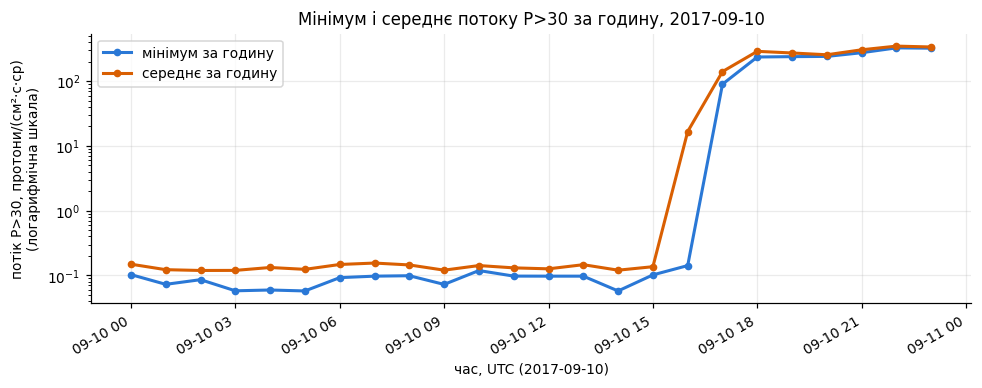


година 16:00 — мінімум 0.142, середнє 16.716, різниця в 118 разів


In [ ]:
ПОТІК = 'P>30'
СИНІЙ, ПОМАРАНЧ = '#2a78d6', '#d95f02'
ДОБА = '2017-09-10'        #межі

доба = A.loc[A['ts'].dt.normalize() == ДОБА].set_index('ts')[ПОТІК] #тільки 10 вер .dt.normalize() обрізає час і лишає саму дату, тому порівняння з '2017-09-10' дає True для всіх 288 пʼятихвилинок тієї доби. Далі групуємо по часу
по_годинах = доба.resample('h').agg(['min', 'mean'])         #resample('h') складає ці 288 записів у 24 купки, по одній на годину.
print(по_годинах.to_string())

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(по_годинах.index, по_годинах['min'],  marker='o', ms=4, lw=2,
        color=СИНІЙ,    label='мінімум за годину')
ax.plot(по_годинах.index, по_годинах['mean'], marker='o', ms=4, lw=2,
        color=ПОМАРАНЧ, label='середнє за годину')
ax.set_yscale('log')
ax.set_xlabel('час, UTC (%s)' % ДОБА)
ax.set_ylabel('потік %s, протони/(см²·с·ср)\n(логарифмічна шкала)' % ПОТІК)
ax.set_title('Мінімум і середнє потоку %s за годину, %s' % (ПОТІК, ДОБА))
ax.grid(alpha=0.25)
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

година_події = по_годинах.loc['2017-09-10 16:00']
print()
print('година 16:00 — мінімум %.3f, середнє %.3f, різниця в %.0f разів'
      % (година_події['min'], година_події['mean'], година_події['mean'] / година_події['min']))

**Відповідь 4.2:** *(чим відрізняються криві та коли це важливо)*

До 16:00 обидві криві йдуть майже впритул: потік стоїть на фоновому рівні ≈0.1, усередині
години нічого не змінюється, тому мінімум і середнє відрізняються лише на десятки відсотків.

Різниця стає суттєвою рівно тоді, коли **величина сильно змінюється всередині самої години**.
О 16:00 10 вересня починається протонна подія: перші п'ятихвилинки ще фонові (0.142),
останні вже 64.5. Мінімум за цю годину = 0.142 — він ще «не помітив» події, а середнє = 16.7,
тобто **у 118 разів більше**. Мінімум показує стан на початку сплеску, середнє — всю годину разом.

Загалом: мінімум за вікно консервативний, він тримається за найнижчу точку і тому
**запізнюється на зростанні** (і, навпаки, першим реагує на спад). На стаціонарних ділянках
вибір агрегату не важливий; на фронтах — це різні відповіді на різні питання.
Якби йшлося про попередження про радіаційну небезпеку, мінімум за годину дав би сигнал
із запізненням і небезпеку було б пропущено.

### Завдання 4.3
Об'єднайте три таблиці в одну — назвіть її `M`. Виведіть її розмір і всі рядки,
у яких є хоча б один пропуск.

**Зверніть увагу:** таблиці закінчуються не в один і той самий момент. Тому результат
залежить від того, який тип об'єднання ви оберете (`how='inner'` чи `how='outer'`).
Спробуйте обидва, подивіться, чим відрізняється кількість рядків, і поясніть свій вибір.

In [ ]:
# merge мерджитьдві таблиці по спільному ст ts, ставить поруч рядки з однаковим часом.
# outer це все, що є хоч десь
M_inner = A_год.merge(C[['ts', 'швидкість', 'густина']], on='ts', how='inner')
M_outer = A_год.merge(C[['ts', 'швидкість', 'густина']], on='ts', how='outer')
print("inner: %d рядків,   outer: %d рядків" % (len(M_inner), len(M_outer)))
print()
print('рядок, який є тільки в outer:')
зайвий = M_outer.loc[~M_outer['ts'].isin(M_inner['ts'])]
print(зайвий[['ts', 'P>10_max', 'швидкість', 'густина']].to_string())

#Потім я створюю стовпець доба через .dt.normalize(), який обрізає час і лишає дату, і по ньому приклеюю F10.7, щоб одне добове значення розтягнулося на всі 24 години.
M = M_inner.copy()
M['доба'] = M['ts'].dt.normalize()                    # 2017-09-10 14:00 -> 2017-09-10
M = M.merge(B[['ts', 'F10.7']].rename(columns={'ts': 'доба'}), on='доба', how='left')

print()
print('розмір M:', M.shape)
print('рядків із пропуском хоча б в одному стовпці:', int(M.isna().any(axis=1).sum()))
print()
print(M.loc[M.isna().any(axis=1), ['ts', ПОТІК + '_mean', 'швидкість', 'густина', 'F10.7']].to_string())

inner: 600 рядків,   outer: 601 рядків

рядок, який є тільки в outer:
            ts  P>10_max  швидкість  густина
600 2017-09-22       NaN      381.0      1.0

розмір M: (600, 21)
рядків із пропуском хоча б в одному стовпці: 8

                     ts  P>30_mean  швидкість  густина  F10.7
175 2017-09-04 07:00:00   0.085483        NaN      NaN    140
176 2017-09-04 08:00:00   0.086625        NaN      NaN    140
177 2017-09-04 09:00:00   0.105925        NaN      NaN    140
178 2017-09-04 10:00:00   0.101900        NaN      NaN    140
179 2017-09-04 11:00:00   0.089525        NaN      NaN    140
180 2017-09-04 12:00:00   0.089217        NaN      NaN    140
181 2017-09-04 13:00:00   0.104542        NaN      NaN    140
182 2017-09-04 14:00:00   0.086508        NaN      NaN    140


**Відповідь 4.3:** *(який тип об'єднання обрано, скільки рядків дає кожен і чому)*

обрав inner, бо outer додає рядок, у якому немає нічого, крім вітру, і який тільки додає пропусків. Втрачається одна година з 601, і ця година все одно поза періодом, який покривають усі три джерела.

### Завдання 4.4 — поділ на групи
Щоб далі було що з чим порівнювати, поділіть години на три групи за значенням
**максимуму потоку P>10 за годину**:

| Група | Умова |
|---|---|
| `тиха` | менше 10 |
| `активна` | від 10 до 1000 |
| `дуже активна` | 1000 і більше |

Додайте до `M` стовпець `група` і виведіть, скільки годин потрапило в кожну.

> Це не вигадані числа: саме такі пороги використовує метеослужба космічної погоди
> NOAA. Чому вони саме такі — питання не сьогоднішньої роботи.

In [ ]:
ГРУПИ = ['тиха', 'активна', 'дуже активна']

M['група'] = pd.cut(M['P>10_max'],
                    bins=[-np.inf, 10, 1000, np.inf],   # межі , pd.cut розкидає числа по інтервалах і повертає назву групи замість числа.
                    right=False,                        # !інтервали [a, b): 10 потрапляє в некст стадію!
                    labels=ГРУПИ)

кількість = M['група'].value_counts().reindex(ГРУПИ)
print(кількість.to_string())
print()
print('перевірка меж — мінімум і максимум P>10_max у кожній групі:')
print(M.groupby('група', observed=False)['P>10_max'].agg(['min', 'max', 'count']).to_string())

група
тиха            411
активна         171
дуже активна     18

перевірка меж — мінімум і максимум P>10_max у кожній групі:
                   min      max  count
група                                 
тиха             0.188     9.82    411
активна         10.200   989.00    171
дуже активна  1010.000  1330.00     18


**Самоперевірка етапу 4.**

In [ ]:
assert M is not None, 'таблиця M не побудована'
assert 'ts' in M.columns, 'у таблиці M потрібен стовпець ts'
assert 'група' in M.columns, 'у таблиці M потрібен стовпець «група»'
assert 590 <= len(M) <= 605, 'очікується близько 600 рядків, а є %d — перевірте об’єднання' % len(M)
print('Етап 4 пройдено:', len(M), 'рядків')

Етап 4 пройдено: 600 рядків


---
# Етап 5. П'ять графіків — п'ять питань

Графік будується як **відповідь на питання**, а не «щоб був».

**Вимоги до кожного графіка:**

* підписані обидві осі, з одиницями вимірювання;
* заголовок;
* під графіком, у текстовій клітинці, — **одне речення про дані**.
  Не «на графіку зображено потік протонів», а твердження на кшталт
  «більшість годин потік не перевищує 60, але кілька годин дають значення у сотні разів більші».

> Не кожне питання має відповідь «так, зв'язок є». Якщо на графіку нічого не видно —
> так і напишіть. Відсутність зв'язку — це теж результат, і чесно про неї написати
> важливіше, ніж підбирати ракурс, у якому «щось наче проглядається».

### Графік 1. Як розподілені значення вашого потоку?
Побудуйте гістограму вашого потоку (середнє за годину). Порахуйте окремо середнє
й медіану цього стовпця.

Якщо гістограма вийде нечитабельною — стовпчик біля нуля і порожньо далі — не
залишайте так. Спробуйте побудувати гістограму від логарифма значень
(`np.log10`) і подивіться, що зміниться.

**Питання:** чому середнє й медіана так сильно відрізняються?

середнє  = 18.831
медіана  = 0.1378
середнє / медіана = 137 разів
максимум = 387.1, тобто у 2809 разів більше за медіану

квантилі:
0.25      0.098
0.50      0.138
0.75      0.873
0.90     15.123
0.95    148.192
0.99    356.984

годин зі значенням понад 100: 37
годин, що потрапляють у перший стовпчик лінійної гістограми (<9.7): 513


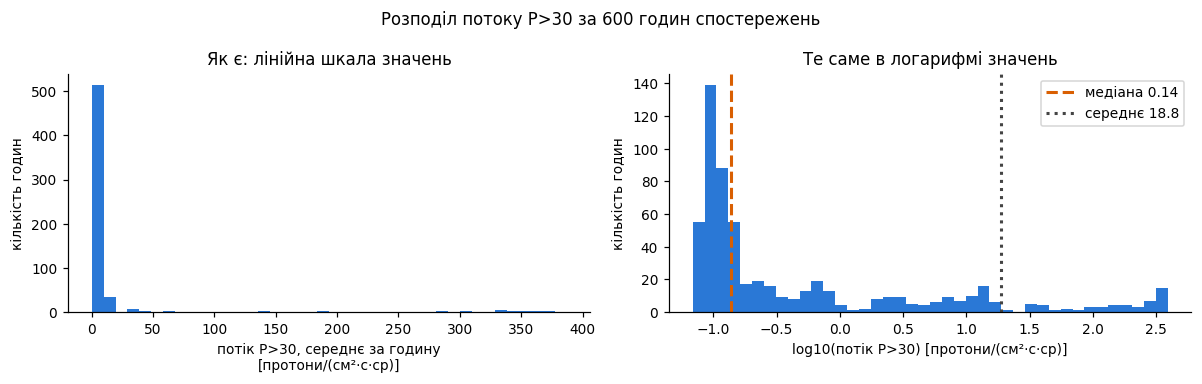

In [ ]:
ряд = M[ПОТІК + '_mean']

print('середнє  = %.3f' % ряд.mean())
print('медіана  = %.4f' % ряд.median())
print('середнє / медіана = %.0f разів' % (ряд.mean() / ряд.median()))
print('максимум = %.1f, тобто у %.0f разів більше за медіану' % (ряд.max(), ряд.max() / ряд.median()))
print()
print('квантилі:')
print(ряд.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).round(3).to_string())
print()
print('годин зі значенням понад 100: %d' % (ряд > 100).sum())
print('годин, що потрапляють у перший стовпчик лінійної гістограми (<%.1f): %d'
      % (ряд.max() / 40, (ряд < ряд.max() / 40).sum()))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))

ax[0].hist(ряд, bins=40, color=СИНІЙ)
ax[0].set_title('Як є: лінійна шкала значень')
ax[0].set_xlabel('потік %s, середнє за годину\n[протони/(см²·с·ср)]' % ПОТІК)
ax[0].set_ylabel('кількість годин')

ax[1].hist(np.log10(ряд), bins=40, color=СИНІЙ)
ax[1].axvline(np.log10(ряд.median()), color=ПОМАРАНЧ, lw=2, ls='--', label='медіана %.2f' % ряд.median())
ax[1].axvline(np.log10(ряд.mean()),   color='#444444', lw=2, ls=':',  label='середнє %.1f' % ряд.mean())
ax[1].set_title('Те саме в логарифмі значень')
ax[1].set_xlabel('log10(потік %s) [протони/(см²·с·ср)]' % ПОТІК)
ax[1].set_ylabel('кількість годин')
ax[1].legend()

fig.suptitle('Розподіл потоку %s за %d годин спостережень' % (ПОТІК, len(ряд)))
fig.tight_layout()
plt.show()

**Висновок:**

розподіл потоку P>30 розтягнутий на три з половиною порядки — у трьох чвертях годин він не перевищує 0.87, тоді як у 37 годин перевищує 100, а максимум (387) у 2800 разів більший за медіану (0.138); саме через ці кілька десятків годин середнє (18.8) виявляється у 137 разів більшим за медіану, тобто «середня година» такого потоку в даних просто не існує.

У лінійній шкалі гістограма нечитабельна: 513 годин із 600 злипаються в один стовпчик біля нуля. Логарифм показує справжню форму — два окремі згустки: фоновий рівень близько 0.1 (спокійні доби) і згусток біля 100–400 (години події 10–13 вересня). Це не «викиди» в сенсі помилок вимірювання, а другий фізичний режим, і медіана описує дані краще за середнє.

### Графік 2. Чи відрізняється швидкість вітру між групами годин?
Побудуйте діаграму розмаху (`boxplot`) швидкості сонячного вітру окремо для кожної
групи з завдання 4.4.

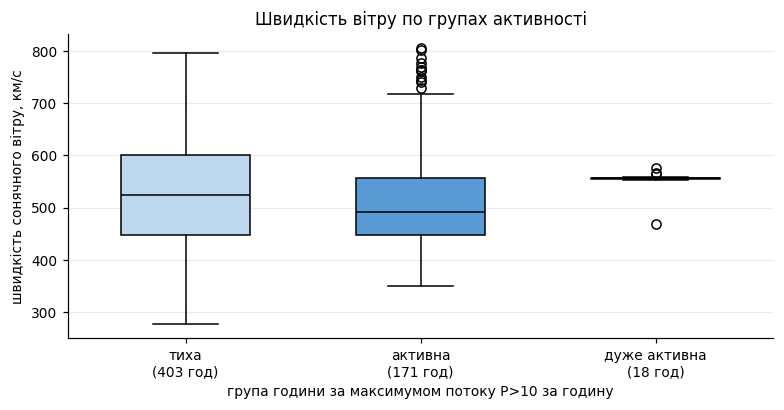

              count   mean    std    min    25%    50%    75%    max
група                                                               
тиха          403.0  511.3  116.2  277.0  448.5  524.0  600.5  795.0
активна       171.0  515.1  103.4  350.0  447.5  492.0  557.0  806.0
дуже активна   18.0  552.9   21.6  469.0  555.0  556.0  557.0  575.0


In [ ]:
дані = [M.loc[M['група'] == g, 'швидкість'].dropna() for g in ГРУПИ]

fig, ax = plt.subplots(figsize=(7.2, 3.8))
bp = ax.boxplot(дані, patch_artist=True, widths=0.55)
for кор, колір in zip(bp['boxes'], ['#bdd7ee', '#5b9bd5', '#1f4e79']):
    кор.set_facecolor(колір)
for медіана in bp['medians']:
    медіана.set_color('#000000')

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['%s\n(%d год)' % (g, len(d)) for g, d in zip(ГРУПИ, дані)])
ax.set_xlabel('група години за максимумом потоку P>10 за годину')
ax.set_ylabel('швидкість сонячного вітру, км/с')
ax.set_title('Швидкість вітру по групах активності')
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

print(M.groupby('група', observed=False)['швидкість'].describe().round(1).to_string())

**Висновок:**

швидкість вітру майже не розрізняє групи, медіани 524, 492 і 556 км/с відрізняються менш ніж на 12%, а «ящики» тихих і активних годин накладаються практично повністю, 277-795 проти 350-806 км/с. Вужчий вигляд «дуже активної» групи це не фізика, а розмір вибірки, бо це всього 18 годин однієї події з розкидом 469-575 км/с. Тобто потік протонів високої енергії і швидкість сонячного вітру це різні явища з різними джерелами: протони прилітають від спалаху за десятки хвилин, а швидкий вітер це потік плазми, який доходить окремо і за свій час. За швидкістю вітру передбачити протонну подію по цих даних не вийде.

### Графік 3. Чи пов'язані змінні вашої пари?
Побудуйте діаграму розсіювання для пари з вашого завдання. Порахуйте коефіцієнт
кореляції між ними.

пар без пропусків: 592
коефіцієнт кореляції Пірсона  r = -0.041
коефіцієнт Спірмена           ρ = +0.014

медіана та максимум густини по діапазонах швидкості:
            count  median   max
швидкість                      
(250, 400]    106     3.0  12.5
(400, 500]    172     2.1  31.7
(500, 600]    189     2.6  17.5
(600, 700]     97     2.6  12.6
(700, 900]     28     2.7   7.0

годин із густиною понад 10: 13, усі при швидкості 355–614 км/с
при швидкості понад 650 км/с (64 годин) густина не перевищила 7.0


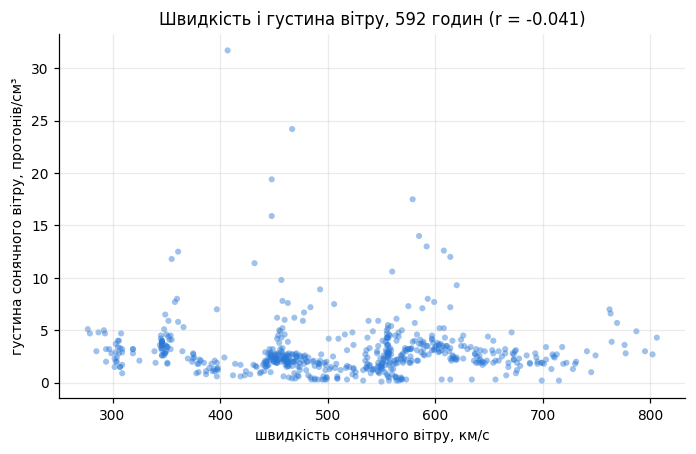

In [ ]:
x, y = M['швидкість'], M['густина']
r_пірсон  = x.corr(y)
r_спірмен = x.corr(y, method='spearman')
print('пар без пропусків: %d' % (x.notna() & y.notna()).sum())
print('коефіцієнт кореляції Пірсона  r = %+.3f' % r_пірсон)
print('коефіцієнт Спірмена           ρ = %+.3f' % r_спірмен)
print()
print('медіана та максимум густини по діапазонах швидкості:')
смуги = pd.cut(x, [250, 400, 500, 600, 700, 900])
print(y.groupby(смуги, observed=False).agg(['count', 'median', 'max']).round(2).to_string())
print()
print('годин із густиною понад 10: %d, усі при швидкості %.0f–%.0f км/с'
      % ((y > 10).sum(), x[y > 10].min(), x[y > 10].max()))
print('при швидкості понад 650 км/с (%d годин) густина не перевищила %.1f'
      % ((x > 650).sum(), y[x > 650].max()))

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.scatter(x, y, s=16, alpha=0.45, color=СИНІЙ, edgecolors='none')
ax.set_xlabel('швидкість сонячного вітру, км/с')
ax.set_ylabel('густина сонячного вітру, протонів/см³')
ax.set_title('Швидкість і густина вітру, %d годин (r = %+.3f)' % ((x.notna() & y.notna()).sum(), r_пірсон))
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

**Висновок:**

лінійного звʼязку немає, r = -0.041 і ρ = +0.014, обидва коефіцієнти практично нульові, і хмара точок не має нахилу. Це підтверджується по діапазонах: медіана густини майже не залежить від швидкості, 2.1-3.0 протонів/см³ в усіх пʼяти смугах від 250 до 900 км/с. Знати швидкість вітру означає не знати про густину нічого.

Але на графіку видно те, чого коефіцієнт не показує, а саме несиметричну верхню межу хмари. Усі 13 годин із густиною понад 10 лежать при швидкості нижче 615 км/с, а на 64 годинах зі швидкістю понад 650 км/с густина не піднялася вище 7.0. Максимум густини падає зі швидкістю: 31.7 у смузі 400-500 км/с проти 7.0 у смузі 700-900. Тобто дуже швидкий і одночасно дуже щільний вітер не трапився жодного разу.

Це обмеження зверху-справа, а не залежність: типове значення не зсувається, зсувається тільки межа можливого. Кореляція такого не ловить у принципі, і це ще одна причина дивитися на графік, а не тільки на число.

### Графік 4. Скільки годин у кожній групі?
Побудуйте стовпчикову діаграму кількості годин за групами. Підпишіть кожен стовпчик
кількістю годин і відсотком від загальної кількості.

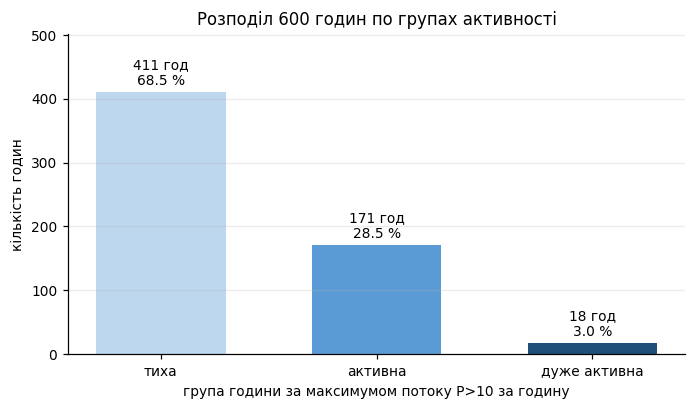

In [ ]:
частки = 100 * кількість / кількість.sum()

fig, ax = plt.subplots(figsize=(6.4, 3.8))
стовпчики = ax.bar(ГРУПИ, кількість.values, color=['#bdd7ee', '#5b9bd5', '#1f4e79'], width=0.6)
for стовпчик, n, p in zip(стовпчики, кількість.values, частки.values):
    ax.text(стовпчик.get_x() + стовпчик.get_width() / 2, n + 6,
            '%d год\n%.1f %%' % (n, p), ha='center', va='bottom')

ax.set_xlabel('група години за максимумом потоку P>10 за годину')
ax.set_ylabel('кількість годин')
ax.set_ylim(0, кількість.max() * 1.22)
ax.set_title('Розподіл %d годин по групах активності' % int(кількість.sum()))
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()

**Висновок:**

**сім годин із десяти (411, 68.5 %) тихі, а дуже активних лише 18 годин, тобто 3 %, менше ніж одна доба з двадцяти пʼяти.** Космічна погода за цей місяць це довгий спокійний фон із дуже коротким сплеском. Будь-яка модель, навчена на такій вибірці наосліп, вгадуватиме «тихо» у 68 % випадків, нічого при цьому не розуміючи. Рідкісний клас тут саме той, заради якого дані й збирають.


### Графік 5. Як усе це виглядало в часі?
Побудуйте лінійний графік максимуму потоку P>10 за годину за весь період спостережень.

Якщо крива виявиться нечитабельною — згадайте, що допомогло в графіку 1.

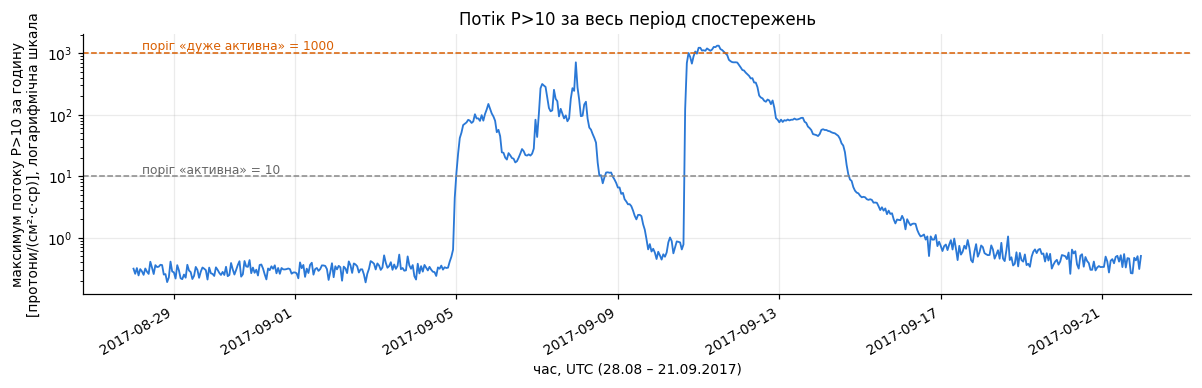

пік: 2017-09-11 11:00:00, P>10_max = 1330
фоновий рівень (медіана): 0.64


In [ ]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.plot(M['ts'], M['P>10_max'], lw=1.2, color=СИНІЙ)
ax.set_yscale('log')
ax.axhline(10,   color='#888888', lw=1, ls='--')
ax.axhline(1000, color=ПОМАРАНЧ,  lw=1, ls='--')
ax.text(M['ts'].iloc[5], 11,   'поріг «активна» = 10',        fontsize=8, color='#666666')
ax.text(M['ts'].iloc[5], 1150, 'поріг «дуже активна» = 1000', fontsize=8, color=ПОМАРАНЧ)

ax.set_xlabel('час, UTC (28.08 – 21.09.2017)')
ax.set_ylabel('максимум потоку P>10 за годину\n[протони/(см²·с·ср)], логарифмічна шкала')
ax.set_title('Потік P>10 за весь період спостережень')
ax.grid(alpha=0.25)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

пік = M.loc[M['P>10_max'].idxmax()]
print('пік: %s, P>10_max = %.0f' % (пік['ts'], пік['P>10_max']))
print('фоновий рівень (медіана): %.2f' % M['P>10_max'].median())

**Висновок:**

28.08-03.09 і 17-21.09 крива стоїть на рівному фоні 0.3-0.5, а між ними дві окремі події: 5-8 вересня з добовим максимумом до 713 і 10-12 вересня до 1330, розділені провалом 9 вересня майже до фону. Розмах між фоном і піком більш ніж три порядки, у 2070 разів, а вище порога «дуже активна» потік був рівно 18 годин.

Без логарифмічної шкали цього не побачити взагалі, у лінійних координатах усі спокійні доби злипаються в пряму лінію на нулі. Видно й асиметрію самої події: підйом 10 вересня різкий, за одну годину на два порядки, а спад розтягнутий на пʼять діб, до 16 вересня. Середнє за добу цю форму повністю приховало б візуально.

---
# Етап 6. Два графіки одних і тих самих даних

Нижче побудовано два графіки. Дані в них **одні й ті самі** — це той самий стовпець
з тієї самої таблиці, жодне число не змінено.

Виконайте клітинку й подивіться на обидва.

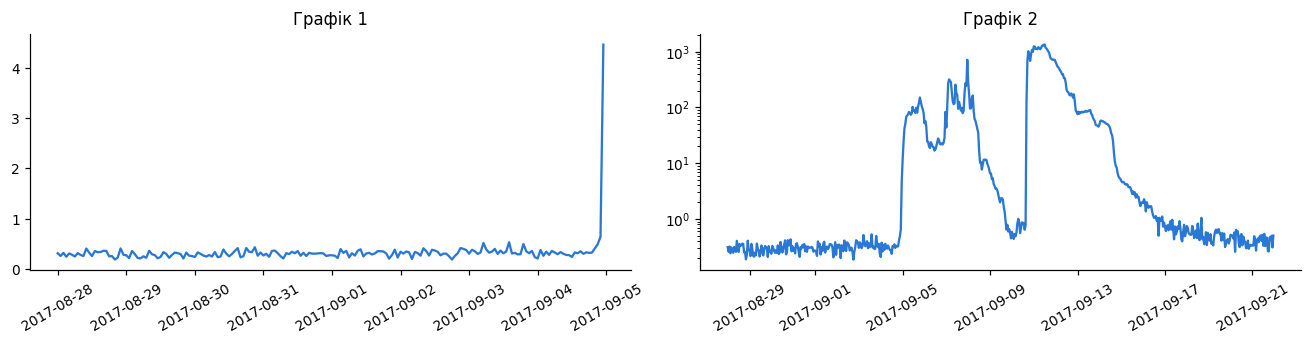

In [ ]:
СТОВПЕЦЬ = 'P>10_max'   # <- впишіть назву свого стовпця з МАКСИМУМОМ P>10 за годину

вікно = M[(M['ts'] >= '2017-08-28') & (M['ts'] < '2017-09-05')]

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))

ax[0].plot(вікно['ts'], вікно[СТОВПЕЦЬ], color='#2a78d6')
ax[0].set_title('Графік 1')
ax[0].tick_params(axis='x', rotation=30)

ax[1].plot(M['ts'], M[СТОВПЕЦЬ], color='#2a78d6')
ax[1].set_yscale('log')
ax[1].set_title('Графік 2')
ax[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Завдання 6.1
Дайте відповідь на три питання:

1. Який висновок про космічну погоду у вересні 2017 року зробить людина, яка бачила
   **тільки перший** графік?
2. Який висновок зробить людина, яка бачила **тільки другий**?
3. Чим ці два графіки відрізняються між собою? Назвіть **дві** відмінності —
   вони обидві є в коді вище.

*Жодне число в обох графіках не підроблене. Різниця виникла тільки через те,
як їх побудували.*

**Відповідь 6.1:**

1. Висновок з першого графіка:

«Космічна погода у вересні 2017 була спокійною». Видно рівну лінію в межах 0.2-0.5 і один вузький сплеск у самому кінці, який виглядає як випадковий викид. Рівень стабільний і безпечний.

2. Висновок з другого графіка:

«У вересні 2017 сталася сильна подія». Видно фон близько 0.3-0.5 і два сплески, 5-8 і 10-13 вересня, які піднімають потік більш ніж на три порядки, до 1330.


3. Дві відмінності між ними:

Різний період: перший графік малює не всі дані, а зріз вікно за 28.08-04.09, тобто 8 діб із 25, які закінчуються якраз тоді, коли подія тільки починається. Другий показує всі 600 годин.
Різна шкала осі Y: перший лінійний, другий логарифмічний через set_yscale('log'). На лінійній шкалі фон 0.4 і пік 1330 неможливо показати разом, фон стає нерозрізненною лінією на нулі.


### Завдання 6.2
Уявіть, що вам потрібно **одним графіком** чесно показати, що відбувалося в цьому
періоді. Побудуйте його самі й підпишіть заголовком, який формулює висновок.

Поясніть у клітинці нижче, чому ви обрали саме такий вигляд.

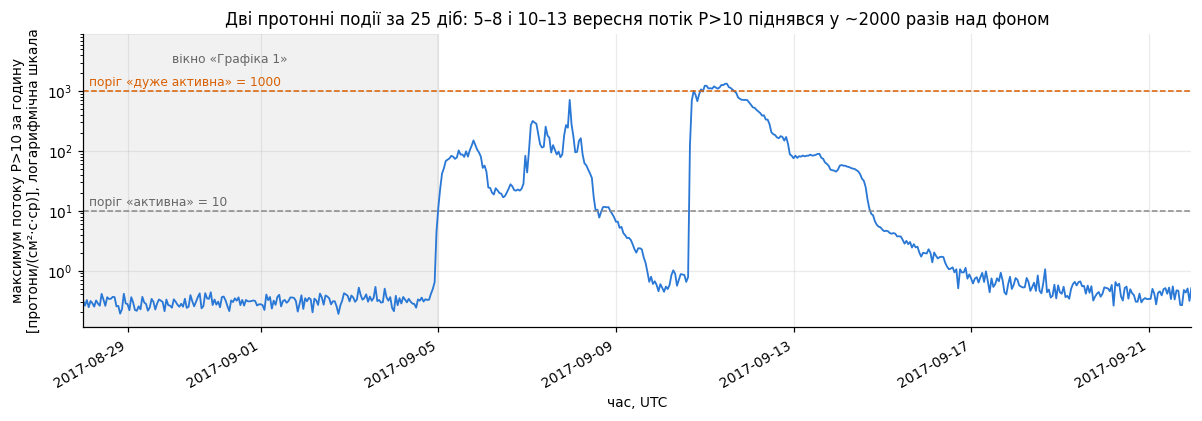

фон (медіана P>10_max) = 0.64, пік = 1330, відношення = 2070


In [ ]:
fig, ax = plt.subplots(figsize=(11, 3.9))

ax.plot(M['ts'], M[СТОВПЕЦЬ], lw=1.2, color=СИНІЙ)
ax.set_yscale('log')

# межі груп — щоб читач бачив не просто криву, а масштаб у зрозумілих одиницях
ax.axhline(10,   color='#888888', lw=1, ls='--')
ax.axhline(1000, color=ПОМАРАНЧ,  lw=1, ls='--')
ax.text(M['ts'].iloc[3], 12,   'поріг «активна» = 10',        fontsize=8, color='#666666')
ax.text(M['ts'].iloc[3], 1250, 'поріг «дуже активна» = 1000', fontsize=8, color=ПОМАРАНЧ)

# вікно з «Графіка 1» — прямо на місці, щоб було видно, що саме воно пропускає
ax.axvspan(pd.Timestamp('2017-08-28'), pd.Timestamp('2017-09-05'),
           color='#000000', alpha=0.055)
ax.text(pd.Timestamp('2017-08-30'), 3000, 'вікно «Графіка 1»', fontsize=8, color='#666666')

ax.set_xlabel('час, UTC')
ax.set_ylabel('максимум потоку P>10 за годину\n[протони/(см²·с·ср)], логарифмічна шкала')
ax.set_title('Дві протонні події за 25 діб: 5–8 і 10–13 вересня потік P>10 піднявся у ~2000 разів над фоном')
ax.grid(alpha=0.25)
ax.set_xlim(M['ts'].min(), M['ts'].max())
ax.set_ylim(M[СТОВПЕЦЬ].min() * 0.6, 9000)
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print('фон (медіана P>10_max) = %.2f, пік = %.0f, відношення = %.0f'
      % (M[СТОВПЕЦЬ].median(), M[СТОВПЕЦЬ].max(), M[СТОВПЕЦЬ].max() / M[СТОВПЕЦЬ].median()))

**Відповідь 6.2:**

Чотири свідомі рішення:

1. **Увесь період, без зрізів.** Якщо показувати частину, то читач мусить бачити, яку саме —
   тому вікно «Графіка 1» я не прибрав, а залишив на місці сірою смугою. Видно, що воно
   закінчується до події.
2. **Логарифмічна шкала.** Дані охоплюють чотири порядки; лінійна шкала фізично не може
   показати і фон, і пік. Логарифм тут не «прикрашання», а єдиний спосіб не приховати
   одну з двох частин даних. Підпис осі про це прямо каже.
3. **Порогові лінії 10 і 1000.** Без них вертикальна вісь — абстрактні числа. З ними
   читач одразу бачить, наскільки подія перевищила межу «дуже активна», не рахуючи в голові логарифми.
4. **Заголовок формулює висновок, а не назву даних.** «Дві протонні події за 25 діб» —
   це те, що я стверджую; читач може одразу перевірити твердження по самому графіку,
   а не переказувати собі, що на осях.

Чого свідомо не робив: не обрізав вісь Y знизу, щоб «підняти» пік, і не згладжував криву —
різкий фронт 10 вересня є властивістю даних, а не шумом.

---
# Етап 7. Три спостереження та ваше питання

### Завдання 7.1
Запишіть **три спостереження** про ці дані, які ви зробили під час роботи.

Спостереження — це твердження, яке спирається на конкретне число або графік з вашого
ноутбука. Не «дані цікаві», а, наприклад, «максимальне значення потоку у 2000 разів
більше за медіанне, і всі такі години припадають на одні й ті самі три доби».

Для кожного вкажіть, **де саме** у вашій роботі його видно.

**Спостереження 1:** у таблиці A рівно **три порожні рядки, і всі три — о 19:20 UTC**:
31.08, 07.09 і 14.09, тобто **рівно через 7 діб**. Це не випадковий збій зв'язку, а регулярна
службова процедура супутника: випадкові втрати не вишиковуються в тижневу сітку з точністю
до п'яти хвилин. Практичний наслідок: пропуски в реальних даних часто мають структуру, і перш
ніж їх «залатати», варто подивитися, коли саме вони трапляються.
*(видно у виводі завдання 3.1 і в клітинці етапу 7.1)*

**Спостереження 2:** три джерела кодують «даних немає» **трьома різними способами**.
У A це порожня клітинка, у C — число `-1` (8 годин поспіль 04.09, 07:00–14:00), а в шапці A
взагалі обіцяно маркер `-1.00e+05`, який у самих даних **не трапляється жодного разу** (перевірено, 0 збігів).
Тому `isna()` знаходить пропуски тільки в A, а пропуски C виглядають як звичайні числа й тихо
потрапляють у середнє — саме це й занизило середню швидкість на 7 км/с.
*(видно в завданнях 3.1, 3.2 і в клітинці етапу 7.1)*

**Спостереження 3:** подія 10–11 вересня настільки домінує, що **24 години навколо піку дають
61 % усього сумарного потоку P>30 за всі 25 діб**, а сам пік (387) у **2800 разів** більший за
медіану. При цьому добовий індекс сонячної активності F10.7 у ці дні дорівнює **80** — тобто
нижче свого середнього, — а свій максимум (140) він мав **4 вересня**, за тиждень до події.
Два показники «сонячної активності» з різних джерел указують на різні дати, і жоден не є
передвісником другого. *(видно на графіку 5, у клітинці етапу 7.1 і в таблиці B)*

In [ ]:
# --- числа під спостереження 1 і 2 ---
print('1) порожні рядки в таблиці A:')
print(пропуски_A[['ts']].assign(час=пропуски_A['ts'].dt.strftime('%H:%M')).to_string(index=False))
print('   інтервали між ними:', [str(d) for d in пропуски_A['ts'].diff().dropna()])

print()
print('2) пропуски в таблиці C — 8 годин поспіль, позначені числом -1, а не порожньою клітинкою.')
print('   у шапці A обіцяно маркер -1.00e+05; скільки разів він реально трапляється в A:',
      int((A[ПОТОКИ_КОЛ] == -1e5).sum().sum()))

print()
print('3) подія 10–11 вересня:')
ряд = M[ПОТІК + '_mean']
i_пік = ряд.idxmax()
вікно24 = M.loc[max(0, i_пік - 12): i_пік + 12, ПОТІК + '_mean']
print('   пік %s: %.1f, медіана %.4f, відношення %.0f' % (M.loc[i_пік, 'ts'], ряд.max(), ряд.median(), ряд.max() / ряд.median()))
print('   24 години навколо піку дали %.1f %% усієї суми потоку за 25 діб' % (100 * вікно24.sum() / ряд.sum()))
print('   F10.7 у добу піку: %d' % M.loc[i_пік, 'F10.7'])
print('   максимум F10.7 за вікно: %d, це доба %s'
      % (B['F10.7'].max(), B.loc[B['F10.7'].idxmax(), 'ts'].strftime('%d.%m.%Y')))

1) порожні рядки в таблиці A:
                 ts   час
2017-08-31 19:20:00 19:20
2017-09-07 19:20:00 19:20
2017-09-14 19:20:00 19:20
   інтервали між ними: ['7 days 00:00:00', '7 days 00:00:00']

2) пропуски в таблиці C — 8 годин поспіль, позначені числом -1, а не порожньою клітинкою.
   у шапці A обіцяно маркер -1.00e+05; скільки разів він реально трапляється в A: 0

3) подія 10–11 вересня:
   пік 2017-09-11 01:00:00: 387.1, медіана 0.1378, відношення 2809
   24 години навколо піку дали 61.0 % усієї суми потоку за 25 діб
   F10.7 у добу піку: 80
   максимум F10.7 за вікно: 140, це доба 04.09.2017


### Завдання 7.2 — ваше індивідуальне питання
Дайте відповідь на додаткове питання зі свого завдання. Відповідь має спиратися
на обчислення: наведіть код і результат, а потім сформулюйте висновок словами.

In [ ]:
доби_по_групах = M.groupby('група', observed=False)['доба'].nunique()
print('різних діб у кожній групі:')
print(доби_по_групах.to_string())
print()
print('усього різних діб у таблиці M:', M['доба'].nunique())
print()
for g in ГРУПИ:
    д = sorted(M.loc[M['група'] == g, 'доба'].unique())
    print('%-14s %2d діб: %s' % (g, len(д), ', '.join(pd.Timestamp(x).strftime('%d.%m') for x in д)))

різних діб у кожній групі:
група
тиха            19
активна          9
дуже активна     2

усього різних діб у таблиці M: 25

тиха           19 діб: 28.08, 29.08, 30.08, 31.08, 01.09, 02.09, 03.09, 04.09, 08.09, 09.09, 10.09, 14.09, 15.09, 16.09, 17.09, 18.09, 19.09, 20.09, 21.09
активна         9 діб: 05.09, 06.09, 07.09, 08.09, 10.09, 11.09, 12.09, 13.09, 14.09
дуже активна    2 діб: 10.09, 11.09


**Відповідь 7.2:**

* у групу **«активні» потрапили години з 9 різних діб** — 05, 06, 07, 08, 10, 11, 12, 13, 14 вересня;
* у групу **«дуже активні» — з 2 діб**: 10 і 11 вересня.

Важливе уточнення, яке видно з розрахунку: **сума по групах (19 + 9 + 2 = 30) більша за
кількість діб у таблиці (25)**. Це не помилка: група присвоюється **годині**, а не добі, тому
одна доба може дати години в дві чи три групи одночасно. 10 вересня — приклад такої доби:
до 16:00 її години тихі, о 16:00–17:00 — активні, а ввечері — дуже активні.

Тобто «дуже активною» подія була лише 18 годин у межах двох календарних діб, і якби ті самі
дані агрегували по добах, а не по годинах, ця подія розмилася б у дві доби із середнім,
заниженим у кілька разів.

---
# Етап 8. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями під час виконання цієї роботи **дозволено**. Це
нормальна інженерна практика, і курс про штучний інтелект не має підстав її забороняти.

Обов'язковою є прозорість: ви вказуєте, де саме і як скористалися інструментом —
так само, як у науковій статті вказують використане програмне забезпечення.
**Задекларована допомога порушенням не є.**

Порушенням є інше: здати роботу, яку ви не можете пояснити. На захисті вас попросять
показати конкретний рядок вашого коду, пояснити, чому він саме такий, і внести в нього
невелику зміну на місці. Якщо код згенеровано, але ви його розумієте — робота
зарахована. Якщо не розумієте — не зарахована, незалежно від того, хто його написав.

### Завдання 8.1
Заповніть словник. Для кожного етапу оберіть одне з формулювань:

* `'ні'` — інструментами ШІ не користувався;
* `'синтаксис'` — питав про назву функції або синтаксис, код писав сам;
* `'код, перевірено'` — код згенеровано, я його прочитав, перевірив і розумію;
* `'текст, перероблено'` — згенеровано чернетку тексту, яку я переписав по суті;
* `'текст, як є'` — згенерований текст залишено майже без змін.

Останній варіант не заборонений, але прямо впливає на оцінку: бали ставляться
за висновки, а не за наявність абзацу.

In [ ]:
ІНСТРУМЕНТИ_ШІ = 'Claude'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етапи 1-2, читання файлу та розбір таблиць': 'синтаксис',
    'етап 3, паспорт даних і дивні значення': 'синтаксис',
    'етап 4, об\'єднання таблиць': 'синтаксис',
    'етап 5, побудова графіків': 'код, перевірено',
    'етап 5, формулювання висновків': 'текст, перероблено',
    'етапи 6-7, порівняння графіків і спостереження': 'текст, перероблено'
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно:
# які числа звірили, що переписали, де знайшли помилку.
ЩО_ПЕРЕВІРЕНО = 'Звіряв правильність назв функцій pandas для обробки даних. Для графіків використав згенерований код як основу. Висновки згенерував як чернетку і повністю переписав, спираючись на власне розуміння отриманих результатів.'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-який
# результат цієї роботи та внести зміни в код на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [ ]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}

assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено пункти декларації: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s. Оберіть з переліку вище.' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше, що саме ви перевірили '
                                           '(зараз %d символів, потрібно щонайменше 120)'
                                           % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'

print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-46s %s' % ('автор:', ПІБ))
print('%-46s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-46s %s' % (k + ':', v))
print('-' * 78)
print('перевірено автором:')
print(ЩО_ПЕРЕВІРЕНО)
print('=' * 78)
print('Автор підтверджує, що може пояснити кожен рядок коду під час захисту.')

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                         Мартин Максим Ігорович
інструменти:                                   Claude
------------------------------------------------------------------------------
етапи 1-2, читання файлу та розбір таблиць:    синтаксис
етап 3, паспорт даних і дивні значення:        синтаксис
етап 4, об'єднання таблиць:                    синтаксис
етап 5, побудова графіків:                     код, перевірено
етап 5, формулювання висновків:                текст, перероблено
етапи 6-7, порівняння графіків і спостереження: текст, перероблено
------------------------------------------------------------------------------
перевірено автором:
Звіряв правильність назв функцій pandas для обробки даних. Для графіків використав згенерований код як основу. Висновки згенерував як чернетку і повністю переписав, спираючись на власне розуміння отриманих результатів.
Автор підтверджує, що може пояснити кожен рядок коду під час захисту

---
# Крок 9. Збереження результату та фінальна самоперевірка

Об'єднана таблиця знадобиться вам у лабораторних роботах № 3 і № 4 — збережіть її
й не втрачайте до кінця семестру.

In [ ]:
M.to_csv('master_hourly.csv', index=False)
print('збережено:', M.shape)

збережено: (600, 22)


In [ ]:
# --- фінальна самоперевірка --------------------------------------------------
перевірки = {
    'ПІБ і варіант заповнено':        bool(ПІБ) and bool(ВАРІАНТ),
    'таблиця A (7200 рядків)':        len(A) == 7200,
    'таблиця B (25 рядків)':          len(B) == 25,
    'таблиця C (601 рядок)':          len(C) == 601,
    'таблиці об’єднано':              M is not None and 590 <= len(M) <= 605,
    'стовпець «група» є':             'група' in M.columns,
    'усі дати у 2017 році':           int(pd.to_datetime(M['ts']).dt.year.min()) == 2017,
    'декларацію заповнено':           bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)

if all(перевірки.values()):
    print('\nТехнічна частина роботи виконана.')
    print('Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     таблиця A (7200 рядків)
OK     таблиця B (25 рядків)
OK     таблиця C (601 рядок)
OK     таблиці об’єднано
OK     стовпець «група» є
OK     усі дати у 2017 році
OK     декларацію заповнено

Технічна частина роботи виконана.
Тепер переконайтеся, що заповнені ВСІ клітинки з відповідями та висновками,
і виконайте Kernel → Restart & Run All перед здачею.
